## Comprobación del número de píxeles de cada clase

In [1]:
import numpy as np
import glob
import os

def read_seg_centers(fichero):
    """Lee el fichero de centros (.raw) y devuelve los índices de los píxeles centrales."""
    try:
        # Los centros suelen tener cabecera: H, V, nseg (uint32)
        cabecera = np.fromfile(fichero, count=3, dtype=np.uint32)
        H, V, nseg = cabecera
        # El resto son los índices de los centros
        datos = np.fromfile(fichero, count=H*V, offset=3*4, dtype=np.uint32)
        # Filtramos posibles valores nulos o fuera de rango si nseg es menor que H*V
        # En tu código original se devuelven todos los datos leídos
        return datos, nseg
    except Exception as e:
        print(f"Error leyendo centros {fichero}: {e}")
        return None, 0

def leer_clases_pgm(ruta_archivo):
    """Lee el PGM y devuelve un array plano con la clase de cada píxel."""
    try:
        with open(ruta_archivo, 'rb') as f:
            tipo = f.readline().decode().strip()
            if tipo != 'P5': return None
            
            linea = f.readline().decode()
            while linea.startswith('#') or not linea.strip():
                linea = f.readline().decode()
            
            dimensiones = linea.split()
            while len(dimensiones) < 2:
                dimensiones += f.readline().decode().split()
            
            ancho, alto = map(int, dimensiones[:2])
            linea_max = f.readline().decode().strip()
            while not linea_max or linea_max.startswith('#'):
                linea_max = f.readline().decode().strip()
            max_val = int(linea_max)

            dtype = np.uint8 if max_val < 256 else np.uint16
            datos = np.frombuffer(f.read(), dtype=dtype)
            return datos, max_val
    except Exception as e:
        print(f"Error leyendo PGM {ruta_archivo}: {e}")
        return None, 0

def procesar_dataset(ruta_pgm, ruta_centers):
    """Asocia cada centro de segmento con su clase en el PGM y cuenta."""
    clases_pixeles, max_clase = leer_clases_pgm(ruta_pgm)
    indices_centros, n_segmentos = read_seg_centers(ruta_centers)
    
    if clases_pixeles is None or indices_centros is None:
        return None

    # Obtenemos la clase de cada segmento consultando el PGM en la posición del centro
    # indices_centros contiene el índice plano (y * H + x)
    clases_de_segmentos = clases_pixeles[indices_centros]
    
    # Contamos segmentos por clase
    conteo = np.bincount(clases_de_segmentos, minlength=max_clase + 1)
    
    return {i: int(cantidad) for i, cantidad in enumerate(conteo) if cantidad > 0}

# --- CONFIGURACIÓN DE RUTAS ---
directorio_base = "datosEntrada"
# Buscamos los PGM (Ground Truth)
archivos_pgm = glob.glob(os.path.join(directorio_base, "**", "*.pgm"), recursive=True)

if not archivos_pgm:
    print(f"No se encontraron archivos en: {os.path.abspath(directorio_base)}")
else:
    print(f"*** Procesando {len(archivos_pgm)} datasets (Conteo por Segmentos) ***\n")
    
    for ruta_pgm in archivos_pgm:
        # Intentamos encontrar el archivo de centros correspondiente
        # Basado en tu estructura: si el pgm es 'oitaven_river.pgm', 
        # el centro suele ser 'seg_..._centers.raw' en la misma carpeta.
        carpeta = os.path.dirname(ruta_pgm)
        ficheros_en_carpeta = os.listdir(carpeta)
        
        # Buscamos un fichero que contenga 'centers.raw'
        ruta_centers = None
        for f in ficheros_en_carpeta:
            if "centers.raw" in f.lower():
                ruta_centers = os.path.join(carpeta, f)
                break
        
        if not ruta_centers:
            print(f"SALTANDO: No se encontró archivo de centros para {ruta_pgm}")
            continue

        print(f"DATASET: {os.path.basename(carpeta)}")
        print(f"PGM: {os.path.basename(ruta_pgm)}")
        print(f"CENTROS: {os.path.basename(ruta_centers)}")
        
        resultado = procesar_dataset(ruta_pgm, ruta_centers)

        if resultado:
            total_sin_clase_0 = sum(cant for val, cant in resultado.items() if val != 0)
            total_absoluto = sum(resultado.values())
            
            print(f"{'Clase':<10} | {'Segmentos':<15} | {'% (Útiles)':<10}")
            print("-" * 45)
            
            for valor in sorted(resultado.keys()):
                cantidad = resultado[valor]
                if valor == 0:
                    print(f"{valor:<10} | {cantidad:<15} | {'(Sin etiqueta)':>10}")
                else:
                    porcentaje = (cantidad / total_sin_clase_0) * 100 if total_sin_clase_0 > 0 else 0
                    print(f"{valor:<10} | {cantidad:<15} | {porcentaje:>9.2f}%")

            print("-" * 45)
            print(f"Total segmentos con clase (>0): {total_sin_clase_0} ({total_sin_clase_0/total_absoluto*100:.2f}%)")
            print(f"Total segmentos sin clase (0): {total_absoluto-total_sin_clase_0} ({(total_absoluto-total_sin_clase_0)/total_absoluto*100:.2f}%)")
            print(f"Total segmentos imagen:         {total_absoluto}")
        else:
            print(f"Error: No se pudo procesar el dataset.")
        
        print("\n" + "="*50 + "\n")

*** Procesando 8 datasets (Conteo por Segmentos) ***

DATASET: oitaven
PGM: oitaven_river.pgm
CENTROS: seg_oitaven_wp_centers.raw
Clase      | Segmentos       | % (Útiles)
---------------------------------------------
0          | 114531          | (Sin etiqueta)
1          | 912             |      4.21%
2          | 484             |      2.24%
3          | 349             |      1.61%
4          | 128             |      0.59%
5          | 458             |      2.12%
6          | 294             |      1.36%
7          | 6896            |     31.86%
8          | 7573            |     34.98%
9          | 955             |      4.41%
10         | 3599            |     16.63%
---------------------------------------------
Total segmentos con clase (>0): 21648 (15.90%)
Total segmentos sin clase (0): 114531 (84.10%)
Total segmentos imagen:         136179


DATASET: xesta
PGM: xesta_basin.pgm
CENTROS: seg_xesta_wp_centers.raw
Clase      | Segmentos       | % (Útiles)
-----------------------

In [2]:
import numpy as np
import os
import glob

def contar_total_segmentos(ruta_seg):
    """
    Lee un archivo .raw de segmentación y devuelve el número total de segmentos únicos.
    """
    try:
        # 1. LECTURA DE LA CABECERA
        # Leemos los primeros 8 bytes (2 enteros de 32 bits) para el ancho y alto
        cabecera_seg = np.fromfile(ruta_seg, count=2, dtype=np.uint32)
        ancho_seg, alto_seg = cabecera_seg[0], cabecera_seg[1]
        
        # 2. LECTURA DE LOS PÍXELES
        # Leemos el resto saltando la cabecera
        segmentos_pixeles = np.fromfile(ruta_seg, count=ancho_seg * alto_seg, offset=8, dtype=np.uint32)
        
        # 3. CONTEO DE SEGMENTOS ÚNICOS
        # np.unique sobre un array 1D es extremadamente rápido
        total_segmentos = len(np.unique(segmentos_pixeles))
        
        return total_segmentos
    except Exception as e:
        print(f"Error procesando {ruta_seg}: {e}")
        return None


# =========================================================
# SCRIPT PRINCIPAL
# =========================================================
directorio_base = "datosEntrada"
# Buscamos todos los archivos que empiecen por "seg_" y terminen en ".raw"
patron_busqueda = os.path.join(directorio_base, "**", "seg_*.raw")
archivos_raw = glob.glob(patron_busqueda, recursive=True)

# Filtramos para descartar los archivos que contienen los centros
archivos_seg = [archivo for archivo in archivos_raw if not archivo.endswith("_centers.raw")]

if not archivos_seg:
    print(f"No se encontraron archivos de segmentación en: {os.path.abspath(directorio_base)}")
else:
    print(f"*** Se han encontrado {len(archivos_seg)} archivos de segmentación ***\n")
    
    # Imprimimos la cabecera de la tabla
    print(f"{'Carpeta / Archivo':<45} | {'Total Segmentos':<15}")
    print("-" * 65)
    
    # Recorremos los archivos ordenados alfabéticamente
    for archivo in sorted(archivos_seg):
        total = contar_total_segmentos(archivo)
        
        if total is not None:
            # Extraemos el nombre de la carpeta y del archivo para que la tabla sea legible
            nombre_carpeta = os.path.basename(os.path.dirname(archivo))
            nombre_archivo = os.path.basename(archivo)
            nombre_corto = f"{nombre_carpeta}/{nombre_archivo}"
            
            print(f"{nombre_corto:<45} | {total:<15,}".replace(',', '.')) # Formato con puntos para miles
        else:
            print(f"{os.path.basename(archivo):<45} | {'Error':<15}")
            
    print("-" * 65)
    print("¡Conteo finalizado!\n")

*** Se han encontrado 8 archivos de segmentación ***

Carpeta / Archivo                             | Total Segmentos
-----------------------------------------------------------------
das_mestas/seg_mestas_wp.raw                  | 151.531        
eiras_dam/seg_eiras_wp.raw                    | 282.672        
ermidas_creek/seg_ermidas_wp.raw              | 651.257        
ferreiras_river/seg_ferreiras_wp.raw          | 271.469        
mera_river/seg_mera_wp.raw                    | 743.522        
oitaven/seg_oitaven_wp.raw                    | 136.179        
ulla/seg_ulla_wp.raw                          | 257.297        
xesta/seg_xesta_wp.raw                        | 216.211        
-----------------------------------------------------------------
¡Conteo finalizado!



In [3]:
import os
import numpy as np
import math
import glob

def read_pgm_lite(fichero):
    """Lee el Ground Truth para obtener las etiquetas."""
    with open(fichero, "rb") as pgmf:
        header = pgmf.readline().decode()
        line = pgmf.readline().decode()
        while line[0] == '#': line = pgmf.readline().decode()
        (H, V) = map(int, line.split())
        depth = int(pgmf.readline().decode())
        raster = list(pgmf.read(H * V))
    return raster, H, V

def read_seg_centers_lite(fichero):
    """Lee los centros de los segmentos."""
    header = np.fromfile(fichero, count=3, dtype=np.uint32)
    H, V, nseg = header[0], header[1], header[2]
    datos = np.fromfile(fichero, count=H*V, offset=3*4, dtype=np.uint32)
    return datos, H, V, nseg

def calcular_muestras_esperadas_sampler(counts_train):
    """
    Calcula la distribución estadística que genera el WeightedRandomSampler
    usando la fórmula del código: weight = 1.0 / sqrt(count) / 2
    """
    total_train = sum(counts_train)
    if total_train == 0: return [0] * len(counts_train)

    # 1. Aplicar fórmula de pesos: w = 1 / (sqrt(N) * 2)
    pesos_clase = [1.0/math.sqrt(c) if c > 0 else 0.0 for c in counts_train]
    
    # 2. La probabilidad de elegir una clase es: (conteo_original * peso_clase)
    # Esto resulta en una distribución proporcional a sqrt(N)
    prob_relativa = [c * w for c, w in zip(counts_train, pesos_clase)]
    suma_prob = sum(prob_relativa)
    
    # 3. Muestras que se verán por época (frecuencia esperada)
    esperado = [(p / suma_prob) * total_train for p in prob_relativa]
    return esperado

# Configuración original
SAMPLES = [0.15, 0.05] # [entrenamiento, validacion]
sizex, sizey = 32, 32  # Tamaño del patch

def analizar_datasets(ruta_base):
    if not os.path.exists(ruta_base):
        print(f"Error: La carpeta '{ruta_base}' no existe.")
        return

    subcarpetas = sorted([f.path for f in os.scandir(ruta_base) if f.is_dir()])
    
    for folder in subcarpetas:
        nombre_dataset = os.path.basename(folder)
        print(f"\n{'='*85}")
        print(f" DATASET: {nombre_dataset.upper()}")
        print(f"{'='*85}")
        
        gt_file = glob.glob(os.path.join(folder, "*.pgm"))
        center_file = glob.glob(os.path.join(folder, "*_centers.raw"))
        
        if not gt_file or not center_file:
            print(f" [!] Faltan archivos .pgm o _centers.raw. Saltando...")
            continue
            
        truth, H, V = read_pgm_lite(gt_file[0])
        center, H3, V3, nseg = read_seg_centers_lite(center_file[0])
        
        nclases = max(truth)
        lista = [[] for _ in range(nclases)]
        
        # Filtrado de bordes
        xmin, xmax = int(sizex/2), H - int(math.ceil(sizex/2))
        ymin, ymax = int(sizey/2), V - int(math.ceil(sizey/2))

        for ind in center:
            i, j = ind // H, ind % H
            if i < ymin or i > ymax or j < xmin or j > xmax: continue
            if truth[ind] > 0:
                lista[truth[ind]-1].append(ind)

        # Listas para guardar el reparto de cada clase
        clases_ids = []
        counts_total = []
        counts_train = []
        counts_val = []
        counts_test = []

        for i in range(nclases):
            total_clase = len(lista[i])
            if total_clase == 0: continue
            
            # --- Lógica de reparto de SAMPLES ---
            # Train
            if SAMPLES[0] >= 1: tot0 = int(SAMPLES[0])
            else: tot0 = int(SAMPLES[0] * total_clase)
            
            if tot0 >= total_clase: tot0 = total_clase // 2
            if tot0 <= 0 and total_clase > 0: tot0 = 1
            
            # Val
            if SAMPLES[1] >= 1: tot1 = int(SAMPLES[1])
            else: tot1 = int(SAMPLES[1] * total_clase)
            
            if tot1 >= (total_clase - tot0): tot1 = (total_clase - tot0) // 2
            if tot1 < 1 and total_clase > 0: tot1 = 0
            
            # Test
            test_count = total_clase - tot0 - tot1
            
            clases_ids.append(i + 1)
            counts_total.append(total_clase)
            counts_train.append(tot0)
            counts_val.append(tot1)
            counts_test.append(test_count)

        # Calcular efecto del sampler sobre el conjunto de TRAIN
        muestras_sampler = calcular_muestras_esperadas_sampler(counts_train)

        # Cabecera de la tabla
        header = f"{'Clase':<6} | {'Total':<7} | {'Train':<7} | {'Val':<6} | {'Test':<7} | {'Frec. Época':<12} | {'Aumento':<8}"
        print(header)
        print("-" * 85)

        for idx in range(len(clases_ids)):
            # Un multiplicador > 1 significa que la clase se repite (oversampling)
            # Un multiplicador < 1 significa que se ven menos muestras de las disponibles (undersampling)
            multiplicador = muestras_sampler[idx] / counts_train[idx] if counts_train[idx] > 0 else 0
            
            fila = (f"C{clases_ids[idx]:02d}    | {counts_total[idx]:<7} | {counts_train[idx]:<7} | "
                    f"{counts_val[idx]:<6} | {counts_test[idx]:<7} | {muestras_sampler[idx]:<12.2f} | "
                    f"x{multiplicador:.2f}")
            print(fila)
        
        print(f"{'='*85}\n")

# Ejecutar el análisis
analizar_datasets('datosEntrada')


 DATASET: DAS_MESTAS
Clase  | Total   | Train   | Val    | Test    | Frec. Época  | Aumento 
-------------------------------------------------------------------------------------
C02    | 4583    | 687     | 229    | 3667    | 1096.06      | x1.60
C07    | 17085   | 2562    | 854    | 13669   | 2116.63      | x0.83
C08    | 1414    | 212     | 70     | 1132    | 608.87       | x2.87
C10    | 16113   | 2416    | 805    | 12892   | 2055.44      | x0.85


 DATASET: EIRAS_DAM
Clase  | Total   | Train   | Val    | Test    | Frec. Época  | Aumento 
-------------------------------------------------------------------------------------
C01    | 1929    | 289     | 96     | 1544    | 345.26       | x1.19
C02    | 424     | 63      | 21     | 340     | 161.20       | x2.56
C03    | 726     | 108     | 36     | 582     | 211.06       | x1.95
C04    | 233     | 34      | 11     | 188     | 118.42       | x3.48
C05    | 111     | 16      | 5      | 90      | 81.24        | x5.08
C06    | 29      | 

In [4]:
import re
import pandas as pd
import glob
import os

# Función que permite procesar el log asociado a un experimento y devuelve 3 elementos: 
# el resumen del rendimiento y tiempos en cada dataset, las estadisticas globales y el accuracy por clase.
def procesar_log_detallado(ruta_archivo):

    # Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    # Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    # Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        # 1. Obtenemos el nombre del dataset"""  """
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        # 2. Extraemos el OA y AA finales obtenidos sobre el dataset
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        # NUEVO: 2.5 Extraemos las medidas de tiempo
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        # Si se han encontrado el OA y el AA se añaden al resumen de resultados
        if oa_match and aa_match:
            datos_dataset = {
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2))
            }
            
            # Añadimos los tiempos si los encuentra (por si algún log antiguo no los tiene, evitamos errores)
            if tiempo_total_match:
                datos_dataset["Tiempo Total (s)"] = float(tiempo_total_match.group(1))
            else:
                datos_dataset["Tiempo Total (s)"] = None
                
            if tiempo_epoca_match:
                datos_dataset["Tiempo por Época (s)"] = float(tiempo_epoca_match.group(1))
            else:
                datos_dataset["Tiempo por Época (s)"] = None

            resumen_data.append(datos_dataset)
            
        # 3. Extraemos el accuracy obtenido para cada clase
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            # Obtenemos los resultados para cada clase (ignorando la desviación típica de la clase, como en tu código original)
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            # Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    # Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    # Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    # Transformamos la tabla de clases a formato ancho
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    # Calculamos las estadísticas globales
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(),df_resumen["Tiempo Total (s)"].mean(),df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(),df_resumen["Tiempo por Época (s)"].std()]
    }
    
    # Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [5]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo).replace(".log", "")
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]

                t_total_medio = df_res["Tiempo Total (s)"].mean() if "Tiempo Total (s)" in df_res.columns else None
                t_epoca_medio = df_res["Tiempo por Época (s)"].mean() if "Tiempo por Época (s)" in df_res.columns else None
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std,
                    "Tiempo Total Medio (s)": t_total_medio,
                    "Tiempo Época Medio (s)": t_epoca_medio
                })
            else:
                print(df_res)

        if datos_comparacion:
            datos_ordenados = sorted(
                datos_comparacion, 
                key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
                reverse=True
            )
            
            
            
            # Definimos anchos fijos para reutilizar y evitar errores de cálculo
            w_rank = 8
            w_metodo = 40  # Aumentado para dar aire a nombres largos
            w_oa = 22
            w_aa = 22

            print(f"\n\n{'='*30} RESUMEN RESULTADOS {'='*30}")

            # Encabezado
            header = f"{'Ranking':<{w_rank}} | {'Método':<{w_metodo}} | {'OA Global (%) ± Std':<{w_oa}} | {'AA Global (%) ± Std':<{w_aa}}"
            print(header)
            print("-" * len(header))

            # Filas
            for i, dato in enumerate(datos_ordenados, start=1):
                oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
                aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
                
                # Usamos las mismas variables de ancho (w_rank, w_metodo, etc.)
                print(f"#{i:<{w_rank-1}} | {dato['Prueba']:<{w_metodo}} | {oa_str:<{w_oa}} | {aa_str:<{w_aa}}")

            print("=" * len(header))
    
        return datos_comparacion

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        df_comparacion = pd.DataFrame(datos_comparacion)

        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        
        # Comprobamos si los tiempos se han extraído correctamente y no son todos nulos
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        
        num_graficas = 3 if tiene_tiempos else 2
        fig, axes = plt.subplots(num_graficas, 1, figsize=(12, 7 * num_graficas), sharex=False)
        
        # Asignamos los ejes
        ax1 = axes[0]
        ax2 = axes[1]

        # --- 1. Gráfica de Precisión ---
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'], alpha=0.8
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Precisión (%)')
        ax1.set_ylim(80, 100)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Forzar la leyenda en un sitio fijo
        ax1.legend(["OA Global", "AA Global"], loc='upper right')

        # --- 2. Gráfica de Desviación ---
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', ax=ax2, color=['#2ca02c', '#d62728'], alpha=0.8
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Variación (%)')
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        
        ax2.legend(["OA Std", "AA Std"], loc='upper right')

        # --- 3. Gráfica de Tiempos (SOLO TIEMPO POR ÉPOCA) ---
        if tiene_tiempos:
            ax3 = axes[2]
            
            df_comparacion.set_index('Prueba')[['Tiempo Época Medio (s)']].plot(
                kind='bar', 
                ax=ax3, 
                color=['#8c564b'], # Color marrón para diferenciarlo de los anteriores
                alpha=0.8
            )
            
            ax3.set_title('Coste Computacional (Tiempo Medio por Época)', fontsize=14, fontweight='bold')
            ax3.set_ylabel('Tiempo (segundos)')

            ax3.set_ylim(bottom=0.8)

            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            ax3.legend(["Tiempo Medio por Época"], loc='upper right')

        # Ajustes finales
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Experimentos')
        
        plt.tight_layout()
        plt.show()

## Resultados sin usar el aumentado de la clase minoritaria en el dataloader

In [7]:
#Leemos los resultados asociados a las ejecuciones sin usar el oversampling
ruta_carpeta = "resultadosPruebas"

datos_orig=imprimirResultados(ruta_carpeta)

No se encontraron archivos .log en la carpeta 'resultadosPruebas'.


In [8]:
graficaComparacionModelos(datos_orig)

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [9]:
ruta_carpeta = "Codigos_AumentadoClaseMinoritaria/resultadosPruebasAumentado"

datos_aum=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX_aumentado ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
        oitaven   94.69        0.24   92.24        0.61             53.02                0.5302
     das_mestas   90.88        0.13   89.22        0.19             93.80                0.9380
      eiras_dam   95.45        0.38   90.66        1.07             38.45                0.3845
  ermidas_creek   97.77        0.19   95.84        0.56             60.42                0.6042
ferreiras_river   91.32        0.08   77.93        0.84            133.39                1.3339
     mera_river   90.52        0.15   77.32        5.05            152.20                1.5220
           ulla   98.67        0.26   98.00        0.75              4.53                0.0453
          xesta   98.01        0.11   92.61        0.74            149.08         

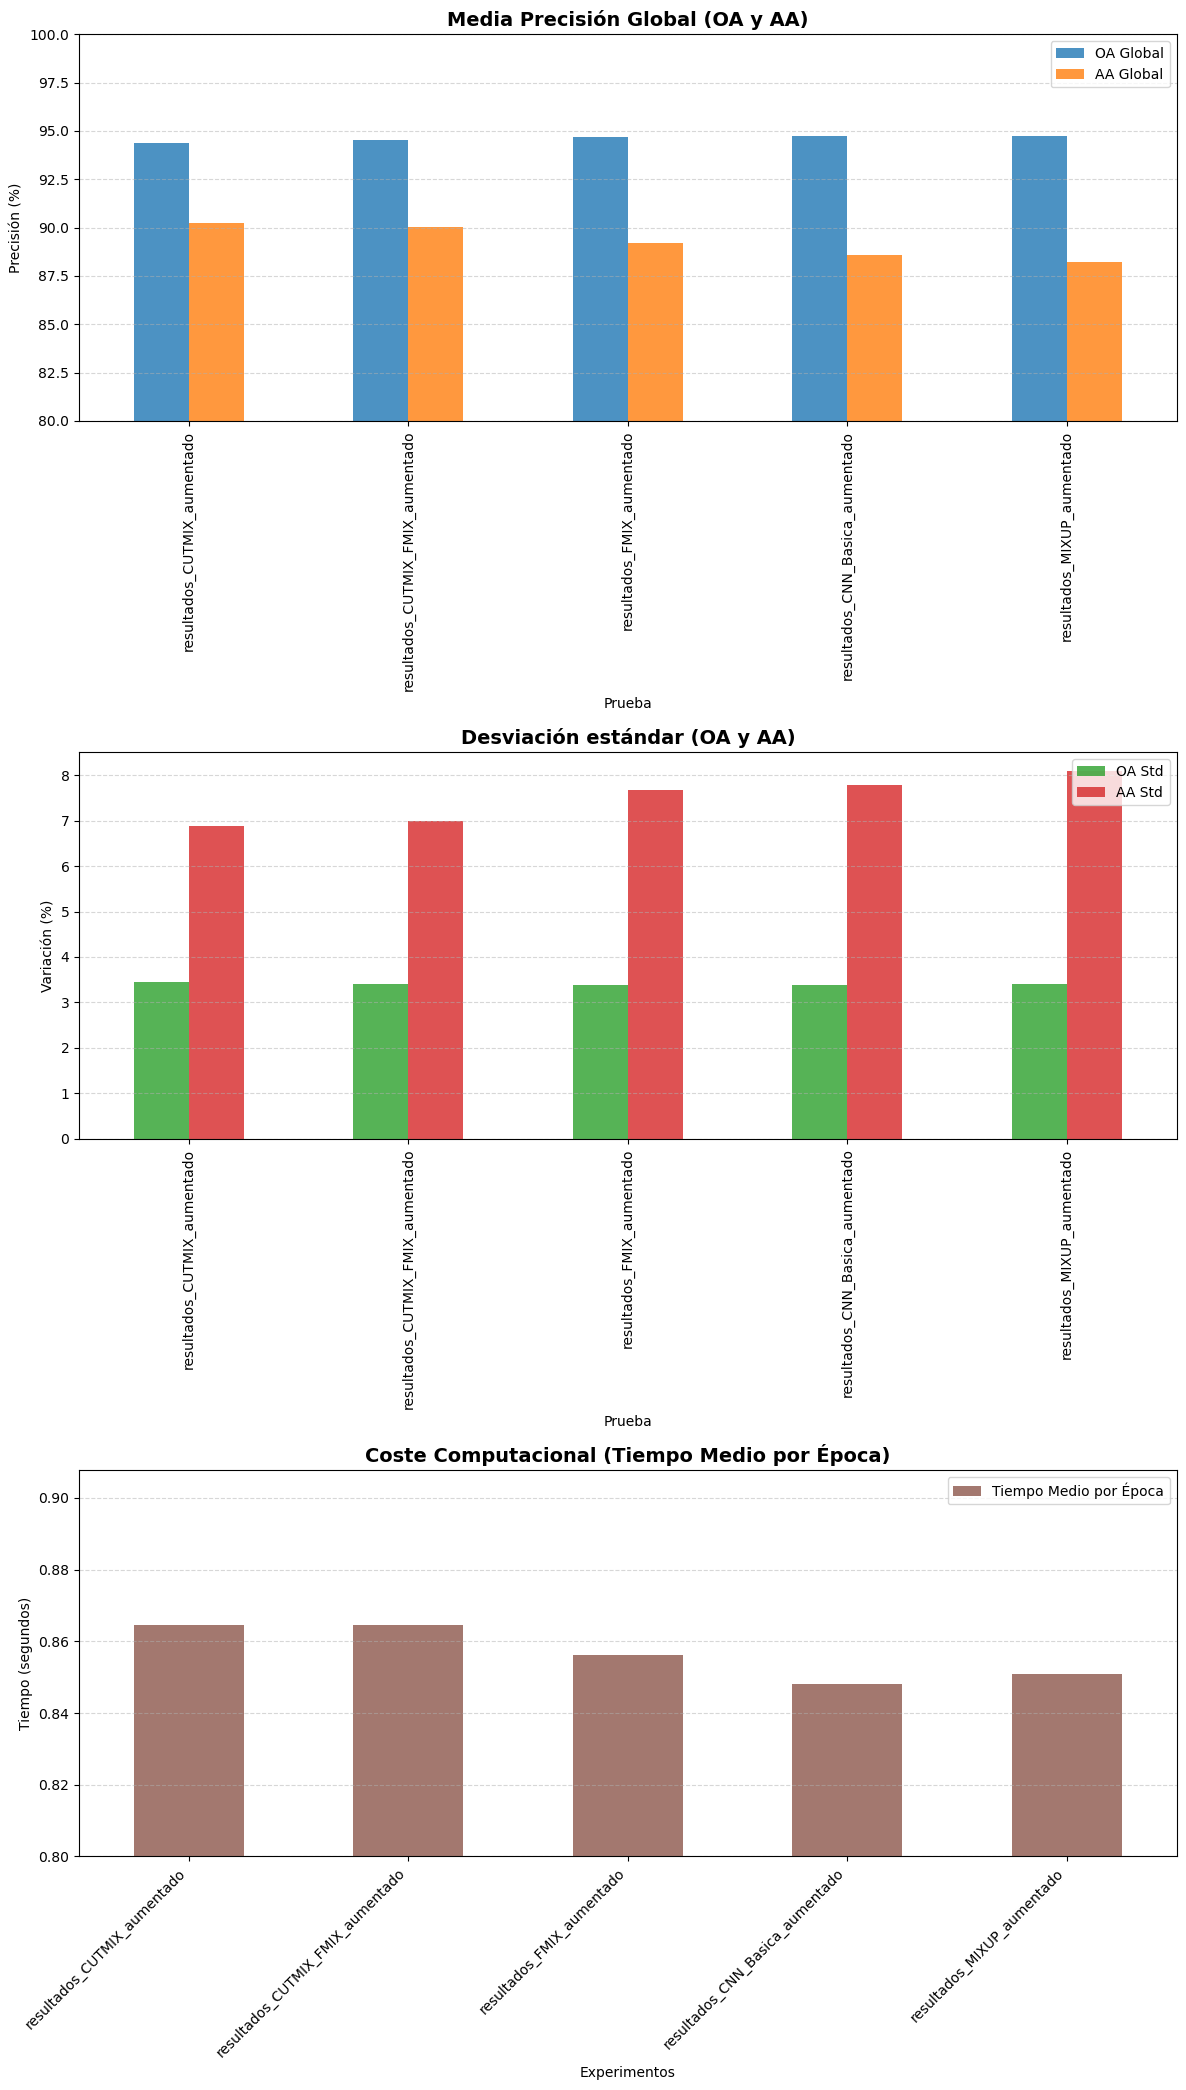

In [10]:
graficaComparacionModelos(datos_aum)

## Comparación de cada versión

In [11]:
# --- 2. UNIFICAR LOS DATOS PARA LA COMPARACIÓN ---
datos_comparacion = []

if datos_orig and datos_aum:
    # Convertimos la lista de diccionarios de la carpeta aumentada en un diccionario
    # donde la clave sea el nombre de la prueba (quitando el sufijo "_aumentado")
    # para poder buscar fácilmente su pareja original.
    dict_aum = {d["Prueba"].replace("_aumentado", ""): d for d in datos_aum}

    for d_orig in datos_orig:
        nombre_base = d_orig["Prueba"]
        
        # Si la prueba original tiene su respectiva versión aumentada, las combinamos
        if nombre_base in dict_aum:
            d_aum = dict_aum[nombre_base]
            datos_comparacion.append({
                "Prueba": nombre_base,
                "OA_Orig": d_orig["OA Global (%)"],
                "OA_Aum": d_aum["OA Global (%)"],
                "AA_Orig": d_orig["AA Global (%)"],
                "AA_Aum": d_aum["AA Global (%)"],
                "OA_Std_Orig": d_orig["OA Std (%)"],
                "OA_Std_Aum": d_aum["OA Std (%)"],
                "AA_Std_Orig": d_orig["AA Std (%)"],
                "AA_Std_Aum": d_aum["AA Std (%)"]
            })

# --- 3. GRÁFICA Y TABLA COMPARATIVA GLOBAL ---
if datos_comparacion:
    df_comp = pd.DataFrame(datos_comparacion)
    # Ordenamos de mayor a menor basándonos en AA_Aum
    df_comp = df_comp.sort_values(by='AA_Aum', ascending=False)
    
    # Definimos las columnas que queremos mostrar y graficar
    cols_medias = ['OA_Orig', 'OA_Aum', 'AA_Orig', 'AA_Aum']
    cols_stds = ['OA_Std_Orig', 'OA_Std_Aum', 'AA_Std_Orig', 'AA_Std_Aum']
    nombres_legibles = ['OA (Original)', 'OA (Aumentado)', 'AA (Original)', 'AA (Aumentado)']

    print("\n" + "="*80)
    print("=== TABLA RESUMEN GLOBAL COMPARATIVA (Media ± Desviación) ===")
    print("="*80)
    
    # Creamos el dataframe resumen con formato "Media ± Desviación"
    df_resumen = pd.DataFrame()
    df_resumen['Prueba'] = df_comp['Prueba']
    df_resumen['OA (Original)'] = df_comp.apply(lambda x: f"{x['OA_Orig']:.2f} ± {x['OA_Std_Orig']:.2f}", axis=1)
    df_resumen['OA (Aumentado)'] = df_comp.apply(lambda x: f"{x['OA_Aum']:.2f} ± {x['OA_Std_Aum']:.2f}", axis=1)
    df_resumen['AA (Original)'] = df_comp.apply(lambda x: f"{x['AA_Orig']:.2f} ± {x['AA_Std_Orig']:.2f}", axis=1)
    df_resumen['AA (Aumentado)'] = df_comp.apply(lambda x: f"{x['AA_Aum']:.2f} ± {x['AA_Std_Aum']:.2f}", axis=1)
    
    print(df_resumen.to_string(index=False))
    
    # Preparación para la gráfica
    df_plot_medias = df_comp[['Prueba'] + cols_medias].set_index('Prueba')
    df_plot_stds = df_comp[['Prueba'] + cols_stds].set_index('Prueba')
    
    # Renombrar columnas para la leyenda de la gráfica
    df_plot_medias.columns = nombres_legibles
    df_plot_stds.columns = nombres_legibles
    
    colores = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']
    
    ax = df_plot_medias.plot(
        kind='bar', 
        yerr=df_plot_stds.values.T, 
        capsize=3,
        figsize=(12, 7), 
        color=colores,
        error_kw={'alpha': 0.6, 'lw': 1.2}
    )
    
    plt.title('Impacto del Aumento de Clase Minoritaria', fontsize=14, fontweight='bold')
    plt.ylabel('Precisión (%)')
    plt.xticks(rotation=45, ha='right')
    
    # Ajuste dinámico del eje Y para que la gráfica no se vea aplastada
    lim_inferior = min(df_comp[cols_medias].min().min() - 5, 75)
    plt.ylim(lim_inferior, 100) 
    
    plt.legend(title='Versiones', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se pudieron generar los datos de comparación. Verifica que los archivos base y los '_aumentado' existan.")


No se pudieron generar los datos de comparación. Verifica que los archivos base y los '_aumentado' existan.


CutMix y CutMix + FMIX son los que mejores resultados dan en ambos casos.

MixUp obtiene peores resultados en ambos casos, siendo incluso peor que la CNN básica.

 

Esto también ocurre en el dataset mera_river con la clase 5 (0.01% del dataset), donde usar FMIX o CutMix aumenta el accuracy a casi el doble sobre la cnn básica sin aumentado de datos.

Existen casos donde hay clases muy poco representadas, como la clase 9 en ferreiras_river, donde representa el 0.02% del dataset, en este caso la red no logra sacar patrones para reconocer esta clase debido a que existen muy pocos píxeles de la misma.



# Comportamiento de las distintas versiones por cada dataset

In [12]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import os

def graficar_clases_separado_limpio(dataset_objetivo):
    modelos_base = ["CNN_Basica", "CUTMIX", "FMIX", "MIXUP", "CUTMIX_FMIX"]
    df_original = pd.DataFrame()
    df_aumentado = pd.DataFrame()

    # 1. RECOLECCIÓN DE DATOS
    for modelo in modelos_base:
        ruta_orig = os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebas", f"resultados_{modelo}.log")
        ruta_aum = os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebasAumentado", f"resultados_{modelo}_aumentado.log")
        
        # Procesar Originales
        if os.path.exists(ruta_orig):
            _, _, df_clases_orig = procesar_log_detallado(ruta_orig)
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                df_original[modelo] = df_clases_orig.loc[dataset_objetivo]
        
        # Procesar Aumentados
        if os.path.exists(ruta_aum):
            _, _, df_clases_aum = procesar_log_detallado(ruta_aum)
            if df_clases_aum is not None and dataset_objetivo in df_clases_aum.index:
                df_aumentado[modelo] = df_clases_aum.loc[dataset_objetivo]

    # 2. FILTRADO: Eliminar clases que no existen en este dataset (valores NaN o 0)
    # Eliminamos filas si todos los modelos tienen NaN o 0 en esa clase
    if not df_original.empty:
        df_original = df_original.dropna(how='all') # Elimina si todo es NaN
        df_original = df_original[(df_original > 0).any(axis=1)] # Elimina si todo es 0
    
    if not df_aumentado.empty:
        df_aumentado = df_aumentado.dropna(how='all')
        df_aumentado = df_aumentado[(df_aumentado > 0).any(axis=1)]

    if df_original.empty and df_aumentado.empty:
        print(f"No hay datos para {dataset_objetivo}")
        return

    # 3. CÁLCULO DEL YMIN DINÁMICO (Decena inferior)
    todos_valores = pd.concat([df_original, df_aumentado]).values.flatten()
    valores_validos = [v for v in todos_valores if v > 0 and not pd.isna(v)]
    
    ymin = (min(valores_validos) // 10) * 10 if valores_validos else 0

    # 4. GENERACIÓN DE GRÁFICAS
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Gráfica 1: Originales
    if not df_original.empty:
        df_original.plot(kind='bar', ax=ax1, width=0.8, colormap='tab10')
        ax1.set_title(f'Dataset: {dataset_objetivo} - ORIGINALES', fontsize=14, fontweight='bold')
        ax1.set_ylim(ymin, 100)
        ax1.set_ylabel('Accuracy (%)')
        ax1.grid(axis='y', linestyle='--', alpha=0.4)
        ax1.legend(title="Modelos", loc='upper left', bbox_to_anchor=(1, 1))

    # Gráfica 2: Aumentados
    if not df_aumentado.empty:
        df_aumentado.plot(kind='bar', ax=ax2, width=0.8, colormap='Set2')
        ax2.set_title(f'Dataset: {dataset_objetivo} - AUMENTO', fontsize=14, fontweight='bold')
        ax2.set_ylim(ymin, 100)
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_xlabel('Clases')
        ax2.grid(axis='y', linestyle='--', alpha=0.4)
        ax2.legend(title="Modelos (Aum)", loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

Generando gráficas para: das_mestas...


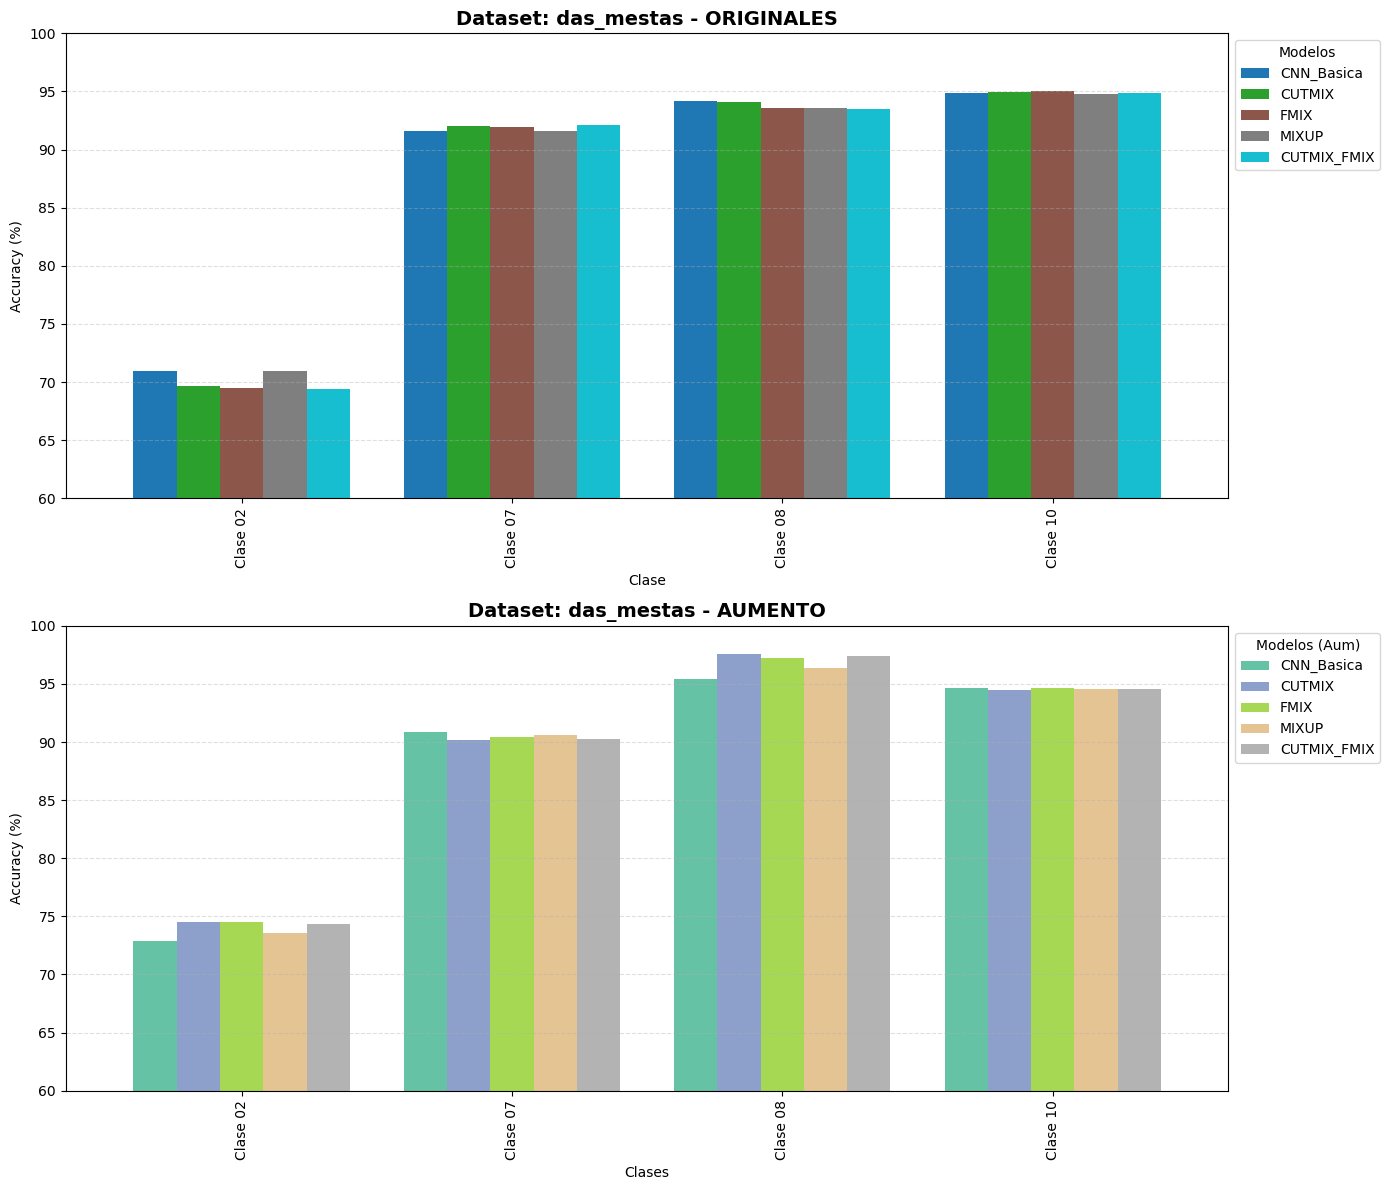


Generando gráficas para: eiras_dam...


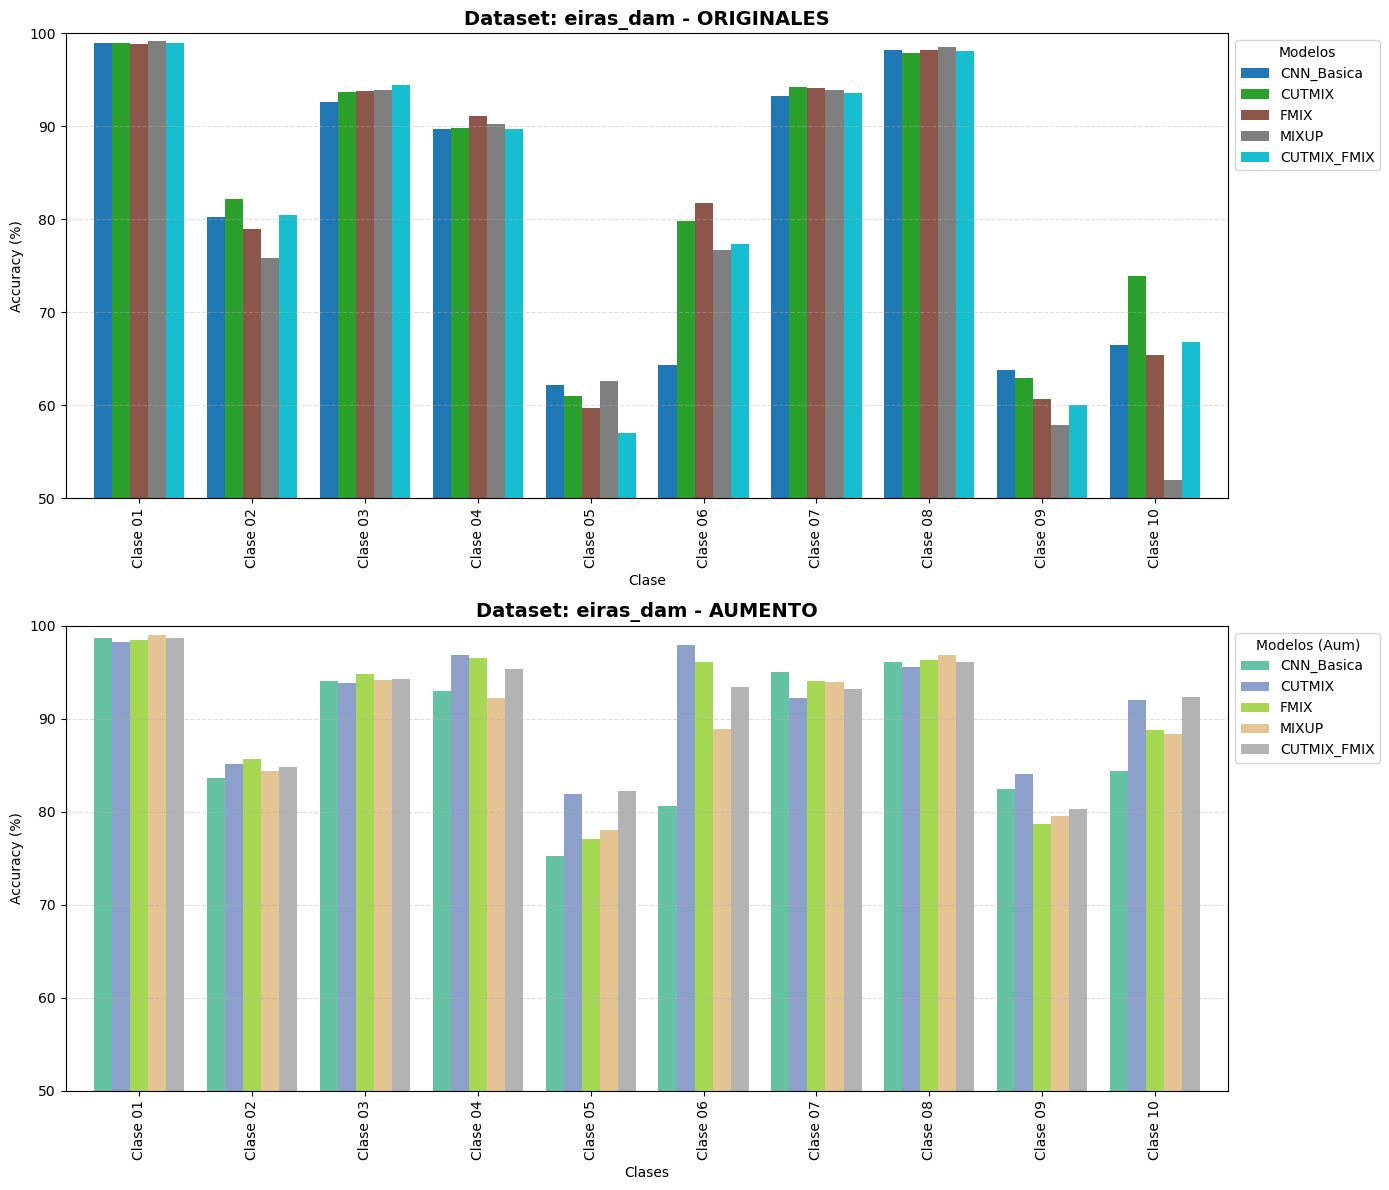


Generando gráficas para: ermidas_creek...


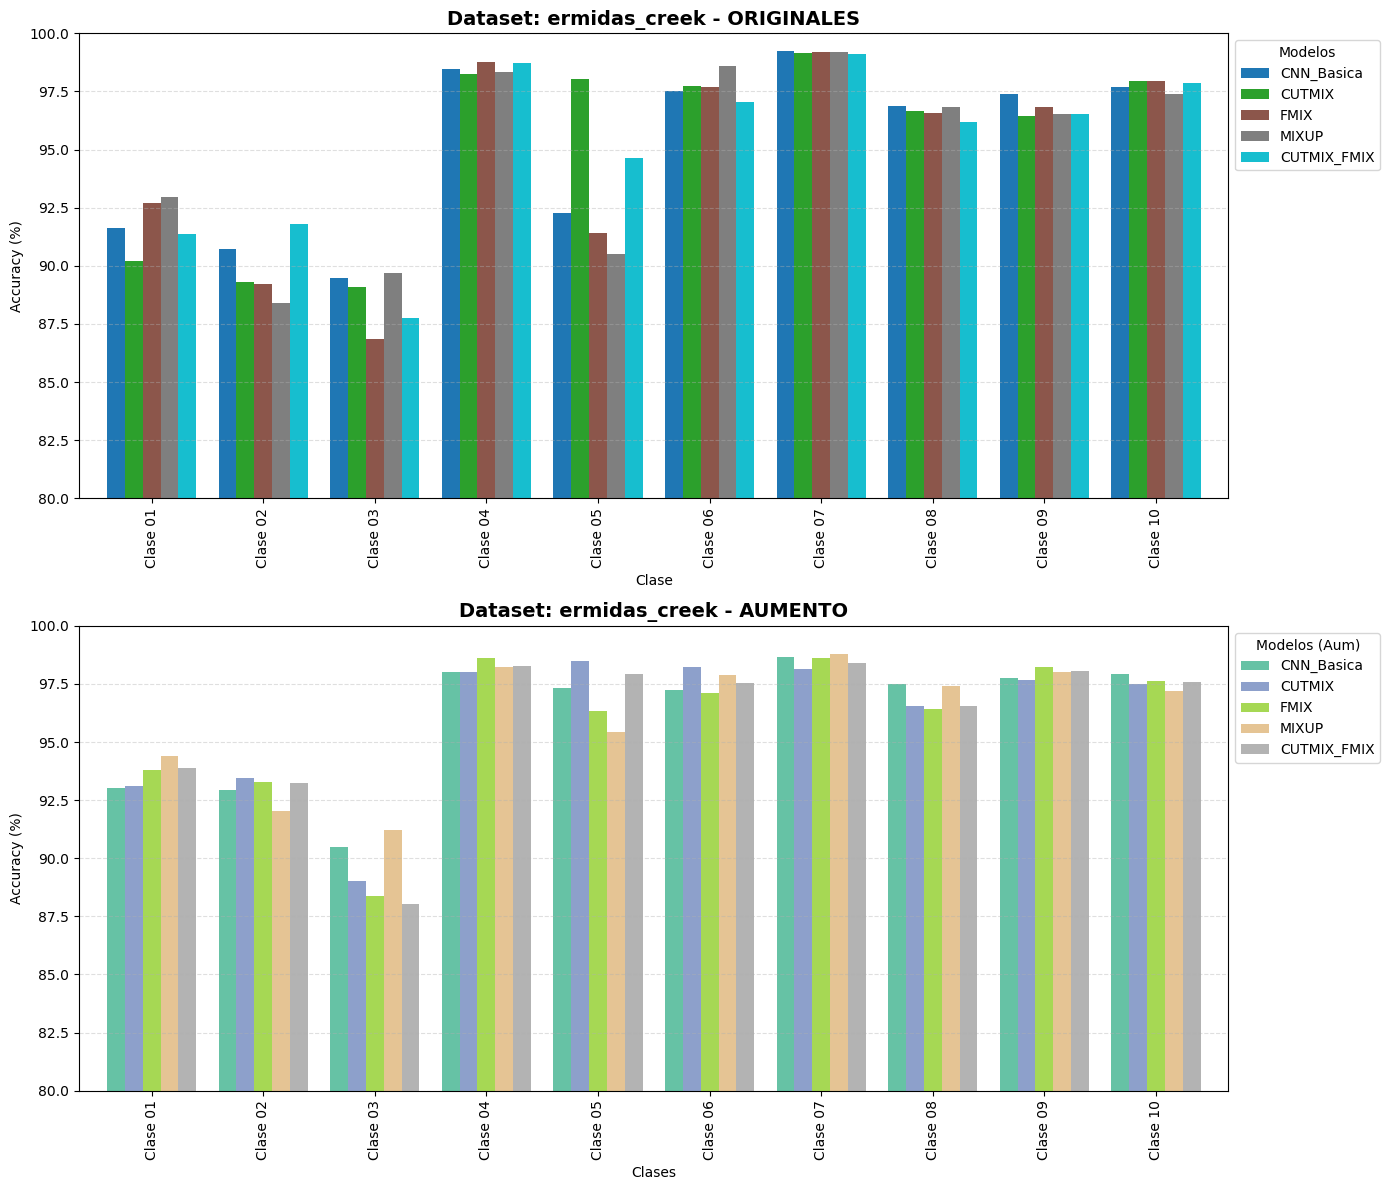


Generando gráficas para: ferreiras_river...


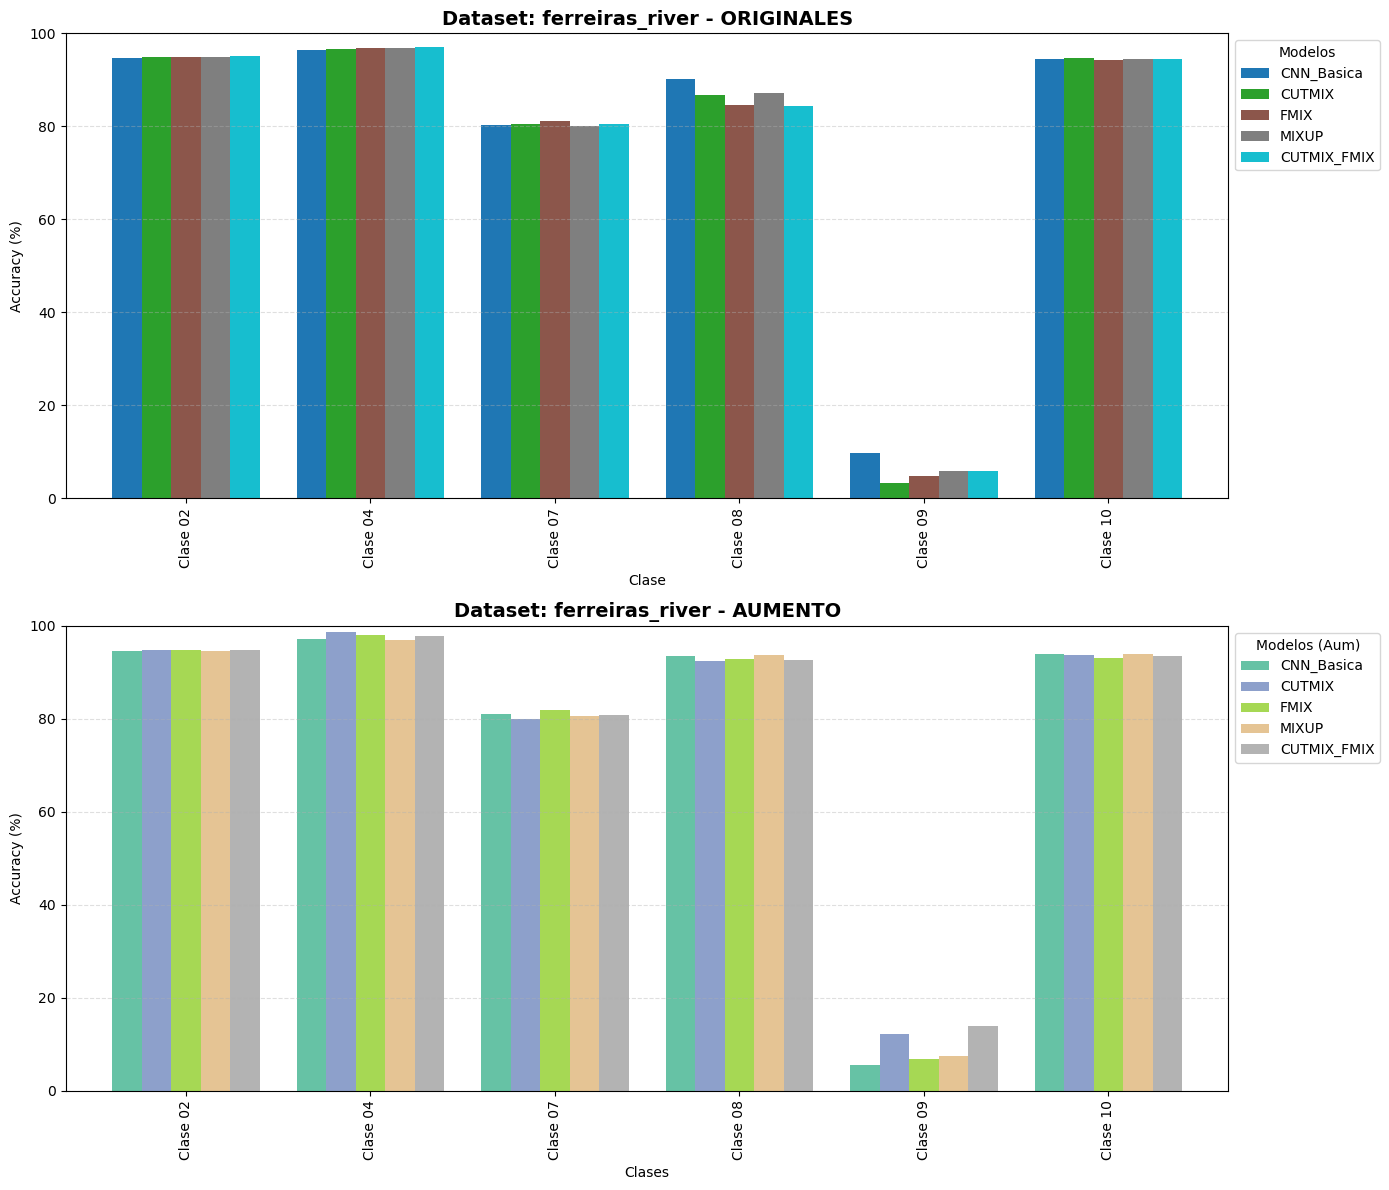


Generando gráficas para: mera_river...


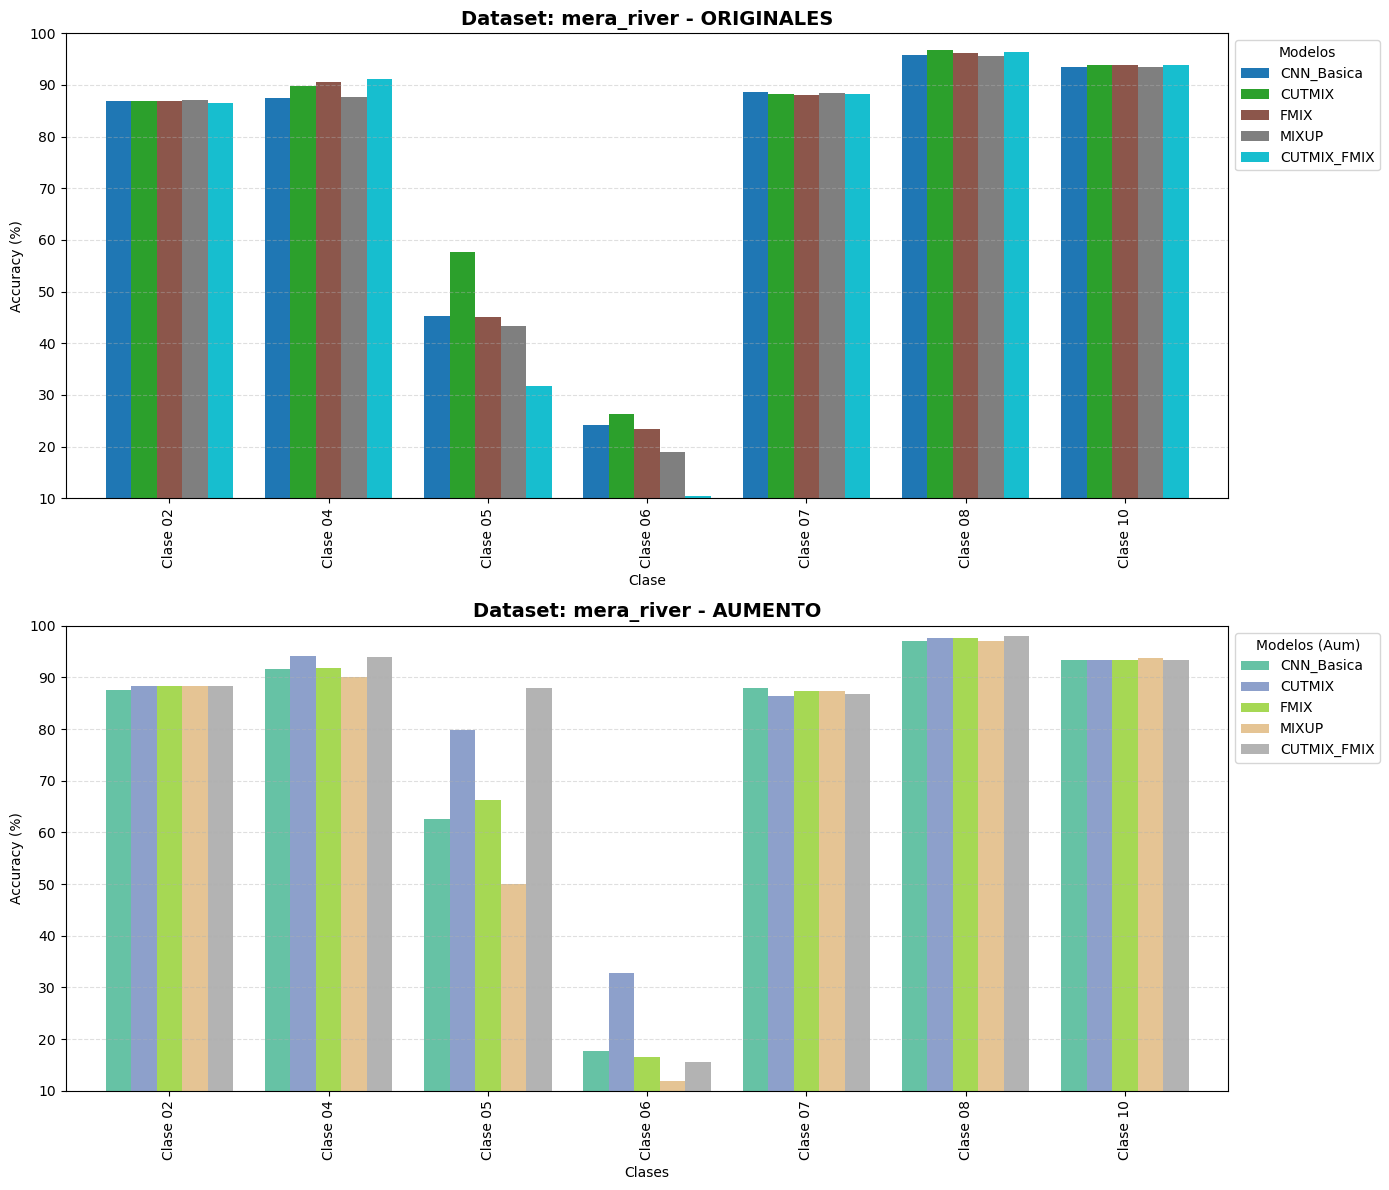


Generando gráficas para: oitaven...


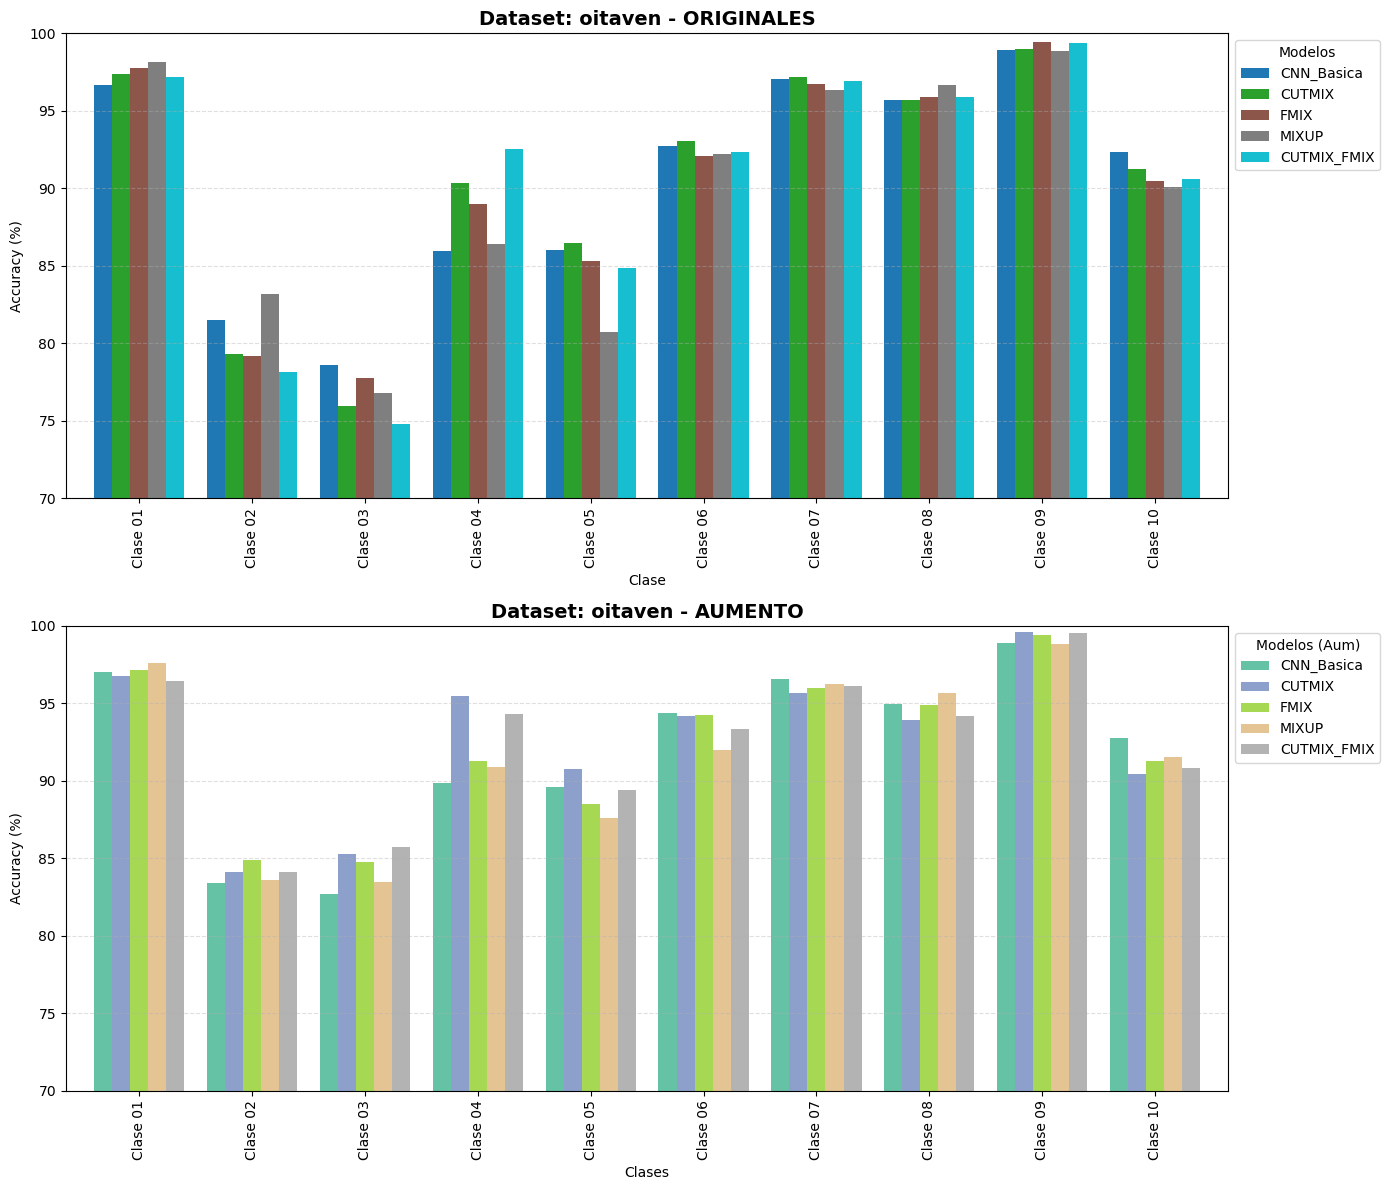


Generando gráficas para: ulla...


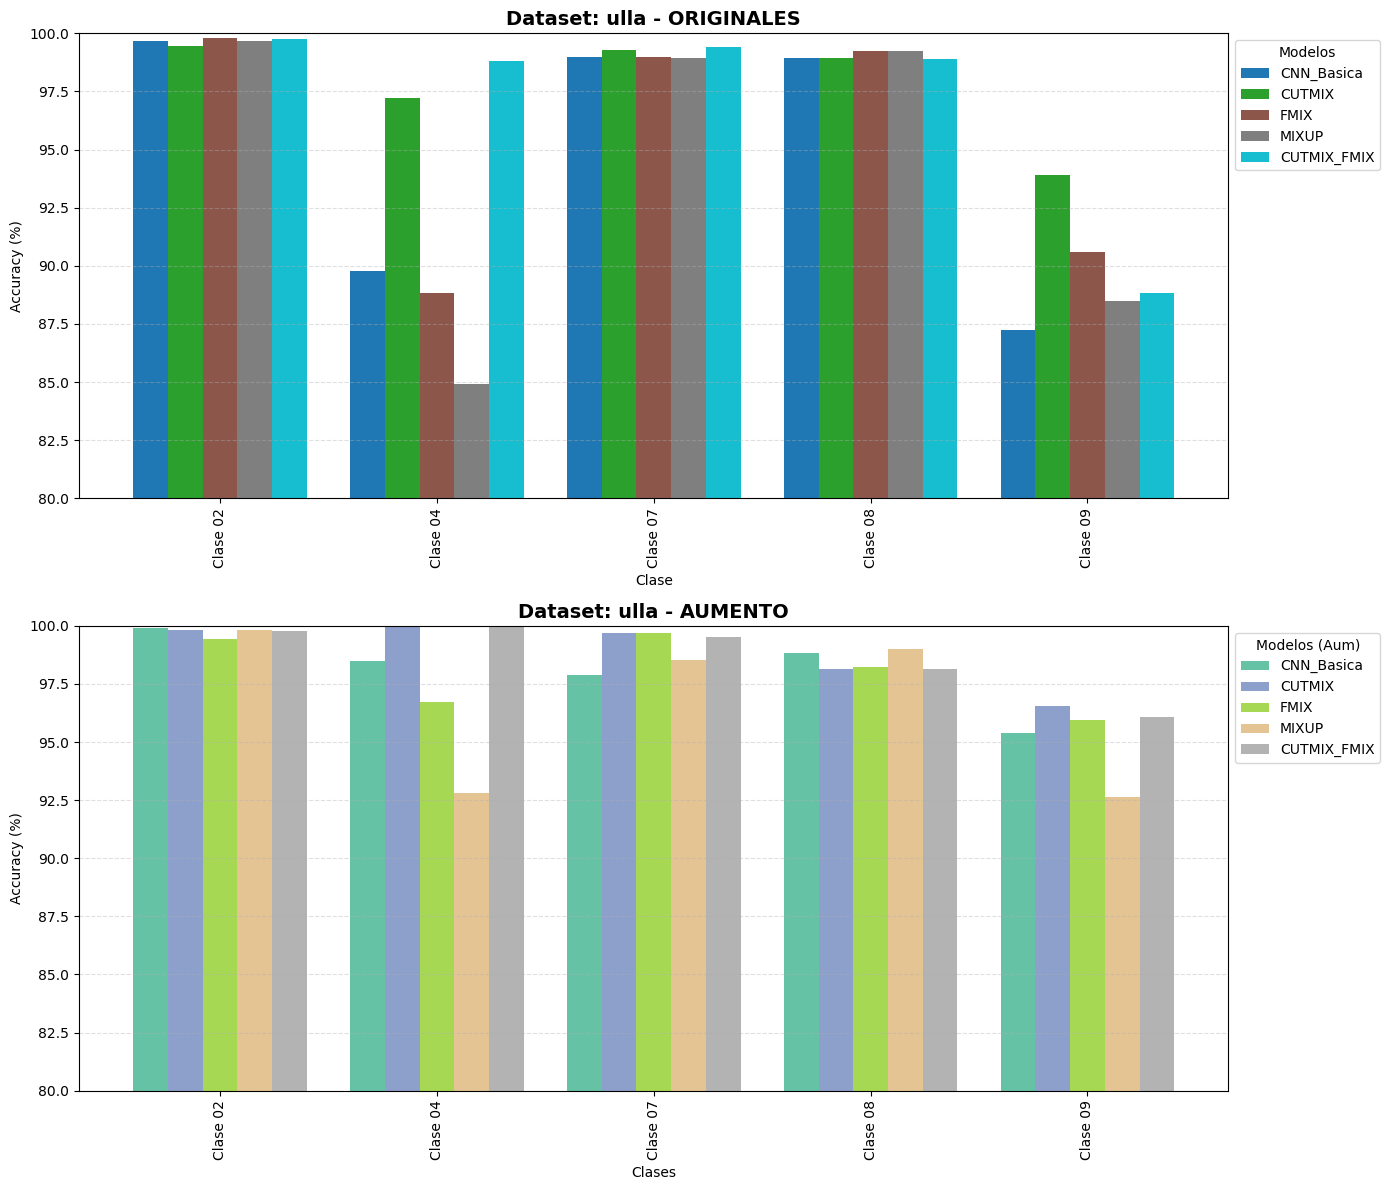


Generando gráficas para: xesta...


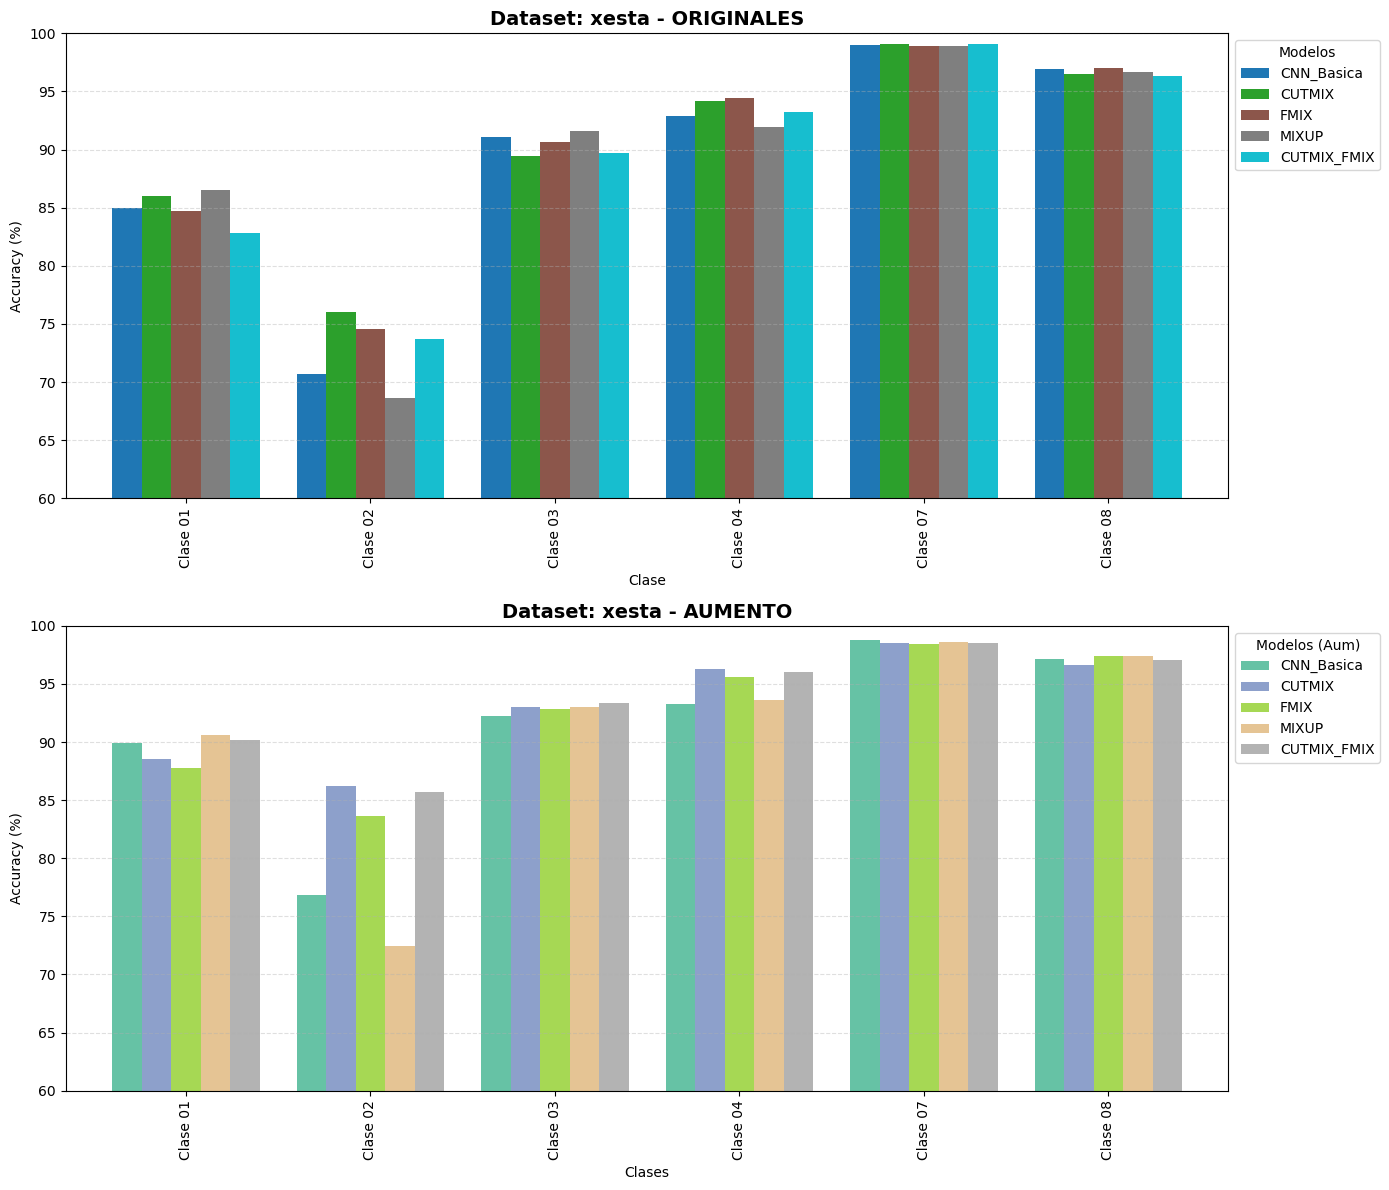

In [13]:
# 1. Obtener la lista de todos los datasets disponibles en tus logs
def obtener_lista_datasets():
    # Usamos cualquier archivo de la carpeta original para extraer los nombres
    archivos = glob.glob(os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebas", "*.log"))
    if not archivos:
        return []
    
    # Procesamos el primero que encontremos para sacar los nombres de los indices
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# 2. Ejecutar la gráfica para cada dataset encontrado
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        print(f"\nGenerando gráficas para: {ds}...")
        graficar_clases_separado_limpio(ds)